Thus far, we have implemented the data sampling and attention mechanism and
coded the LLM architecture. It is now time to implement a training function and
pretrain the LLM

In [17]:
import torch
import torch.nn as nn
import numpy as np

# 5.1 Evaluating generative text models

## 5.1.1 Using GPT to generate text

In [27]:
import torch
import sys
sys.path.append('../04_feedforward')
from transformer import GPTModel

# GPT-124M configuration
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,   
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12, 
    "drop_rate": 0.1,      
    "qkv_bias": False
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

# Verify model
total_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded. Total parameters: {total_params:,}")

Model loaded. Total parameters: 162,419,712


Considering the GPT_CONFIG_124M dictionary, the only adjustment we have made com
pared to the previous chapter is that we have reduced the context length (context_
length) to 256 tokens. This modification reduces the computational demands of
training the model, making it possible to carry out the training on a standard laptop
computer.

Using the GPTModel instance, we adopt the generate_text_simple function from
chapter 4 and introduce two handy functions: text_to_token_ ids and token_ids_
to_text. These functions facilitate the conversion between text and token represen
tations, a technique we will utilize throughout this chapter.

First,
the tokenizer converts input text into a series of token IDs (see chapter 2). Second,
the model receives these token IDs and generates corresponding logits, which are vec
tors representing the probability distribution for each token in the vocabulary (see
chapter 4). Third, these logits are converted back into token IDs, which the tokenizer
decodes into human-readable text, completing the cycle from textual input to tex
tual output.

### Listing 5.1 Utility functions for text to token ID conversion

In [28]:
import tiktoken
sys.path.append('../04_feedforward')
from utils import generate_text_simple

def text_to_token_ids(text, tokenizer):
    """Convert text to token IDs with batch dimension."""
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    """Convert token IDs back to text."""
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

# Test
start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


Next, we will calculate a loss metric for the generated outputs. This loss serves as a
progress and success indicator of the training progress

### 5.1.2 Calculating the text generation loss

In [12]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
               [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                [1107, 588, 11311]])  #  " really like chocolate"]

In [13]:
with torch.no_grad():    
    logits = model(inputs)
probas = torch.softmax(logits, dim=-1)    
print(probas.shape)

torch.Size([2, 3, 50257])


The first number, 2, corresponds to the two examples (rows) in the inputs, also known
as batch size. The second number, 3, corresponds to the number of tokens in each
input (row). Finally, the last number corresponds to the embedding dimensionality,
which is determined by the vocabulary size. Following the conversion from logits to
probabilities via the softmax function, the generate_text_simple function then con
verts the resulting probability scores back into text


In [14]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [16]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1:"
      f"{token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1: Armed heNetflix


In [17]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)
text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4541e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


In [18]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [19]:
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


The goal is to get the average log probability as close to 0 as possible by updating the
model’s weights as part of the training process

In [20]:
#negative avg log prob is just avg log prob multiplied by -1
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


In deep learning, the term for turning this negative
value, –10.7940, into 10.7940, is known as the cross entropy loss. PyTorch comes in
handy here, as it already has a built-in cross_entropy function that takes care of all
these six steps in figure 5.7 for us.

## TL;DR - Cross entropy loss tells you how wrong your model is.
### Cross entropy loss
At its core, the cross entropy loss is a popular measure in machine learning and deep
learning that measures the difference between two probability distributions—typically, the true distribution of labels (here, tokens in a dataset) and the predicted distribution from a model (for instance, the token probabilities generated by an LLM).
In the context of machine learning and specifically in frameworks like PyTorch, the
cross_entropy function computes this measure for discrete outcomes, which is
similar to the negative average log probability of the target tokens given the model’s
generated token probabilities, making the terms “cross entropy” and “negative average log probability” related and often used interchangeably in practice.

| Term | What it is |
|------|-----------|
| **Logits** | Raw model output (any real number) |
| **Probabilities** | Normalized logits via softmax (0 to 1, sum to 1) |

In [22]:
print("Logits shape:", logits.shape)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


For the cross_entropy loss function in PyTorch, we want to flatten these tensors
by combining them over the batch dimension:

In [23]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


Remember that the targets are the token IDs we want the LLM to generate, and the logits contain the unscaled model outputs before they enter the softmax function to obtain the probability scores. Previously, we applied the softmax function, selected the probability scores corresponding to the target IDs, and computed the negative average log probabilities. PyTorch's cross_entropy function will take care of all these steps for us.
### TL;DR - Earlier whatever we did to get the loss, there's an inbuilt function in pytorch library for that 

In [24]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


## Perplexity

Perplexity is a measure often used alongside cross entropy loss to evaluate the performance of models in tasks like language modeling. It can provide a more interpretable way to understand the uncertainty of a model in predicting the next token in a sequence. Perplexity measures how well the probability distribution predicted by the model matches the actual distribution of the words in the dataset. Similar to the loss, a lower perplexity indicates that the model predictions are closer to the actual distribution.

Perplexity can be calculated as `perplexity = torch.exp(loss)`, which returns `tensor(48725.8203)` when applied to the previously calculated loss. Perplexity is often considered more interpretable than the raw loss value because it signifies the effective vocabulary size about which the model is uncertain at each step. In the given example, this would translate to the model being unsure about which among 48,725 tokens in the vocabulary to generate as the next token.

| Metric | Range | Meaning |
|--------|-------|---------|
| **Loss** | 0 to ∞ | Raw probability error (hard to interpret) |
| **Perplexity** | 1 to vocab_size | "Effective vocab uncertainty" (easier to interpret) |

## 5.1.3 Calculating the training and validation set losses

In [30]:
# Loading the verdict text file
file_path = r"Z:\LLM_solo\01_tokenization\the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

print(f"Loaded {len(text_data):,} characters")

Loaded 20,479 characters


In [31]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


To implement the data splitting and loading, we first define a train_ratio to use 90%
of the data for training and the remaining 10% as validation data for model evaluation during training:

In [32]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

Using the train_data and val_data subsets, we can now create the respective data
loader reusing the create_dataloader_v1 code from chapter 2:

In [38]:
import sys
sys.path.append('../02_dataloader')
sys.path.append('../03_attention')
from GPTDatasetV1 import GPTDatasetV1
from MultiHeadAttention import MultiHeadAttention
import tiktoken
from torch.utils.data import DataLoader

torch.manual_seed(123)

# Initialize tokenizer
tokenizer = tiktoken.get_encoding("gpt2")

# Create datasets
train_dataset = GPTDatasetV1(
    train_data,
    tokenizer,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"]
)

val_dataset = GPTDatasetV1(
    val_data,
    tokenizer,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"]
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    drop_last=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    drop_last=False,
    num_workers=0
)

print(f"Train loader: {len(train_loader)} batches")
print(f"Val loader: {len(val_loader)} batches")

Train loader: 9 batches
Val loader: 1 batches


## Creating Train and Validation DataLoaders

We split the text data into training (90%) and validation (10%) sets. Then we create two DataLoaders:

1. **Train Loader** - Used during training
   - `shuffle=True` - Randomizes batch order each epoch (helps model generalize)
   - `drop_last=True` - Discards incomplete batches at the end
   - `stride=context_length` - No overlap between samples (more efficient training)

2. **Validation Loader** - Used to evaluate model performance
   - `shuffle=False` - Keep data in order (consistent evaluation)
   - `drop_last=False` - Keep all samples for accurate validation metrics
   - `stride=context_length` - Same as training for consistency

Each batch contains 2 sequences of `context_length` (256) tokens. The DataLoader automatically handles tokenization and batching through the `GPTDatasetV1` class.

**Key Parameters:**
- `batch_size=2` - Process 2 sequences per batch
- `max_length=256` - Each sequence is 256 tokens long
- `stride=256` - Move 256 tokens forward (no overlap)
- `num_workers=0` - Single-threaded (CPU, simple setup)

In [37]:
print("Train loader:")
for x, y in train_loader:
 print(x.shape, y.shape)
print("\nValidation loader:")
for x, y in val_loader:
 print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


Next, we implement a utility function to calculate the cross entropy loss of a given
batch returned via the training and validation loader:

In [39]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
    logits.flatten(0, 1), target_batch.flatten()
    )
    return loss

We can now use this calc_loss_batch utility function, which computes the loss for a
single batch, to implement the following calc_loss_loader function that computes
the loss over all the batches sampled by a given data loader.

### Listing 5.2 Function to compute the training and validation loss

In [41]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
            input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches 


By default, the calc_loss_loader function iterates over all batches in a given data
loader, accumulates the loss in the total_loss variable, and then computes and averages the loss over the total number of batches

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
with torch.no_grad():
 train_loss = calc_loss_loader(train_loader, model, device)
 val_loss = calc_loss_loader(val_loader, model, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.987583372328016
Validation loss: 10.98110580444336


The loss values are relatively high because the model has not yet been trained. For
comparison, the loss approaches 0 if the model learns to generate the next tokens as
they appear in the training and validation sets

## 5.2 Training an LLM

## Training Loop Overview

The training process follows these steps:

### Core Training Loop
1. **Iterate over training epochs** - Multiple passes through the entire training dataset
2. **Iterate over batches** - Process one batch at a time within each epoch
3. **Reset gradients** - Clear old gradients from previous batch (`optimizer.zero_grad()`)
4. **Forward pass** - Calculate loss on current batch
5. **Backward pass** - Compute loss gradients with respect to model weights
6. **Update weights** - Adjust model parameters using gradients (`optimizer.step()`)

### Monitoring & Evaluation
7. **Print losses** - Display training and validation set losses to track progress
8. **Generate sample text** - Visually inspect model quality during training

---

### Key Concepts

**Epoch**: One complete pass over the entire training dataset

**Batch**: A subset of the training data processed together
- Number of batches per epoch = Training set size ÷ Batch size

**Example**: 
- Training set: 4,000 samples
- Batch size: 2
- Batches per epoch: 2,000

These are the standard steps for training deep neural networks in PyTorch.

## Listing 5.3 The main function for pretraining LLMs

In [45]:
def train_model_simple(model, train_loader, val_loader,
                       optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1
 
    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}")
                generate_and_print_sample(
                    model, tokenizer, device, start_context
                )
    
    return train_losses, val_losses, track_tokens_seen

## The evaluate_model Function

The `evaluate_model` function checks how well the model is learning by calculating losses on both training and validation data.

### What it does:

1. **Switches model to evaluation mode** - Disables dropout and gradient tracking (to get clean, reproducible metrics)
2. **Calculates training loss** - How well the model performs on data it saw during training
3. **Calculates validation loss** - How well the model performs on unseen data (real test of learning)
4. **Returns both losses** - So we can track progress and detect overfitting

### Why it matters:

- **Training loss decreasing** = Model is learning
- **Validation loss decreasing** = Model is generalizing well
- **Validation loss increasing while training loss decreases** = Overfitting (model memorized training data but can't generalize)

### Key settings during evaluation:

- `model.eval()` - Turns off dropout (we want consistent predictions, not random)
- `torch.no_grad()` - Disables gradient calculation (we only evaluate, not train)

This function runs every `eval_freq` steps to monitor training progress.

In [46]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

## The generate_and_print_sample Function

The `generate_and_print_sample` function generates text during training to visually check if the model is improving.

### What it does:

1. **Takes a starting text snippet** (e.g., "Every effort moves you")
2. **Converts it to token IDs** - Turns words into numbers the model understands
3. **Feeds it to the model** - Uses `generate_text_simple()` to generate new tokens
4. **Prints the output** - Shows generated text so you can see if it's getting better

### Why it matters:

- **Loss numbers are abstract** - Hard to understand if 2.5 is "good" or "bad"
- **Generated text is concrete** - You can read it and judge quality directly
- **Easy progress tracking** - See how the model goes from gibberish →

In [47]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

## AdamW Optimizer

AdamW is the optimizer we use to update model weights during training.

### What it does:

1. **Adjusts model weights** - Changes weights to minimize loss
2. **Handles learning rates intelligently** - Uses adaptive learning rates (different rates for different parameters)
3. **Applies weight decay** - Penalizes large weights to prevent overfitting

### Why AdamW (not regular Adam)?

**Weight Decay** = A regularization technique that keeps weights small
- Smaller weights = Simpler model = Better generalization
- Prevents overfitting (memorizing training data)

AdamW applies weight decay **correctly**, making it better than regular Adam for LLMs.

### In practice:

```python
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
```

This creates an AdamW optimizer that will update all model parameters during training.

### Why use it for LLMs?

AdamW is the standard choice for training large language models because it:
- Converges faster than regular Adam
- Generalizes better to unseen data
- Is proven to work well with transformer models

In [49]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004, weight_decay=0.1
)

num_epochs = 10

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.781, Val loss 9.933
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,, the the,,,,,,,,,,,,,,,,,,,
Ep 1 (Step 000005): Train loss 8.111, Val loss 8.339
Every effort moves you, the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
Ep 2 (Step 000010): Train loss 6.661, Val loss 7.048
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,, the,,,,,,,,,,,,,,,,,,,,
Ep 2 (Step 000015): Train loss 5.961, Val loss 6.616
Every effort moves you, and, and,, and, and,,, and, and, and,, and,,,, and, and,, and,,,, and,, and,,, and, and,,, and, and
Ep 3 (Step 000020): Train loss 5.726, Val loss 6.600
Every effort moves you, and I had"                                             
Ep 3 (Step 000025): Train loss 5.201, Val loss 6.348
Every effort moves you his! Gisburn. Gisburn to the picture.   "I        "I. "I the of the--and it.  "I

## Training Results

### Loss Improvement

- **Training loss**: 9.781 → 0.391 (huge improvement)
- **Validation loss**: 9.933 → 6.452 (good improvement, but higher than training loss)

### Model Quality Progression

**Early training**: Model only repeats punctuation or words
- Example: "Every effort moves you,,,,,,,,,,"

**After training**: Model generates grammatically correct text
- Example: "Every effort moves you [coherent sentence]"

### Overfitting Signal

The validation loss stays higher than training loss — this is normal. It means:
- Model learned from training data very well
- But struggles slightly on unseen validation data
- This is expected and acceptable behavior

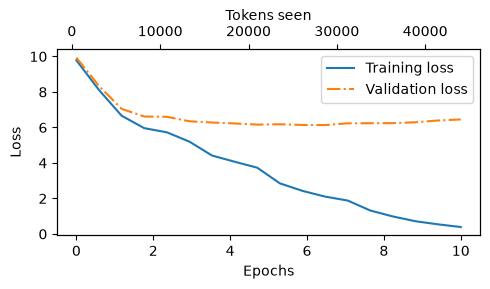

In [50]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
    epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## Overfitting Analysis

### Loss Divergence

After epoch 2:
- **Training loss** keeps decreasing (model memorizes training data)
- **Validation loss** stops improving or increases (can't generalize to new data)
- **Gap grows** between the two losses

### What this means:

The model is **overfitting** — it memorized the training text instead of learning general language patterns.

### Evidence of Overfitting

We can confirm by searching the generated text in the original file. The model outputs exact phrases from "The Verdict" text file, like:

> "quite insensible to the irony"

This phrase appears verbatim in the book, proving the model copied it rather than generated it creatively.

### Key Insight

Overfitting happens because:
- Small dataset (one book)
- Too much training (many epochs)
- Model is large relative to data size

This is normal for this exercise. Production LLMs train on massive diverse datasets to avoid this.

NOTE As mentioned earlier, interested readers can try to train the model on
60,000 public domain books from Project Gutenberg, where this overfitting
does not occur; see appendix B for details. 

## 5.3 Decoding strategies to control randomness

We begin by transferring the model back from the GPU to the CPU since inference with a relatively small model does not require a GPU. Also, after training, we put
the model into evaluation mode to turn off random components such as dropout

In [53]:
model.to("cpu")
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

Next, we plug the GPTModel instance (model) into the generate_text_simple function, which uses the LLM to generate one token at a time:

In [52]:
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you know," was one of the axioms he laid down across the last word.










### 5.3.1 Temperature scaling

In [54]:
vocab = {
 "closer": 0,
 "every": 1,
 "effort": 2,
 "forward": 3,
 "inches": 4,
 "moves": 5,
 "pizza": 6,
 "toward": 7,
 "you": 8,
}
inverse_vocab = {v: k for k, v in vocab.items()}

In [55]:
next_token_logits = torch.tensor(
 [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

As discussed in chapter 4, inside generate_text_simple, we convert the logits into
probabilities via the softmax function and obtain the token ID corresponding to the
generated token via the argmax function, which we can then map back into text via
the inverse vocabulary:

In [56]:
probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

forward


To implement a probabilistic sampling process, we can now replace argmax with
the multinomial function in PyTorch:

In [57]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


The printed output is "forward" just like before. What happened? The multinomial
function samples the next token proportional to its probability score. In other words,
"forward" is still the most likely token and will be selected by multinomial most of
the time but not all the time

In [59]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item()
    for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")
print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


We can further control the distribution and selection process via a concept called
temperature scaling. Temperature scaling is just a fancy description for dividing the logits
by a number greater than 0:

In [60]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

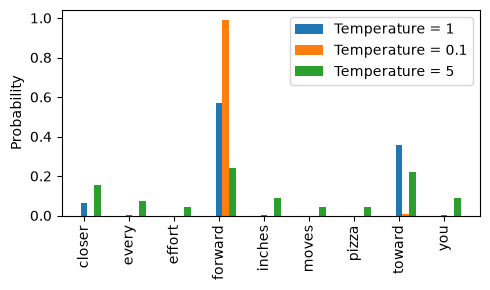

In [61]:
temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T)
                 for T in temperatures]
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i],
                   bar_width, label=f'Temperature = {T}')
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

## Temperature Sampling

Temperature controls how "confident" or "creative" the model is when generating text.

### Temperature = 1 (Default)
- No scaling applied to model probabilities
- Model picks tokens based on learned confidence
- Example: "forward" chosen 60% of the time

### Low Temperature (e.g., 0.1)
- Makes the model very confident
- Always picks the most likely token (~100%)
- Generates: Predictable, safe, boring text
- Behavior: Similar to `argmax()` (always pick the top choice)

### High Temperature (e.g., 5)
- Makes the model less confident
- Picks less likely tokens more often
- Generates: Creative, varied, often nonsensical text
- Example: "every effort moves you pizza" (4% of the time — gibberish)

### Trade-off:
- **Low temp** = Safe but repetitive
- **High temp** = Diverse but risky
- **Temp = 1** = Good balance

Lower temperature is better for factual tasks. Higher temperature is better for creative writing.

### 5.3.2 Top-k sampling

## Top-K Sampling

Top-K sampling improves text generation by limiting choices to only the most likely tokens.

### How it works:

1. **Select top-K tokens** - Keep only the K most likely next tokens
2. **Mask others** - Set all other tokens to negative infinity (-inf)
3. **Recalculate probabilities** - Apply softmax so remaining K tokens sum to 1
4. **Sample from K tokens** - Only these K tokens can be chosen

### Example (K=5):

Model predicts 50,257 possible tokens. With top-5:
- Keep: The 5 most likely tokens
- Discard: The remaining 50,252 tokens

In [62]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [63]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float('-inf')),
    other=next_token_logits
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [64]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


### 5.3.3 Modifying the text generation function

### Listing 5.4 A modified text generation function with more diversity

In [66]:
def generate(model, idx, max_new_tokens, context_size,
             temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        
        logits = logits[:, -1, :]
        
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(
                logits < min_val,
                torch.tensor(float('-inf')).to(logits.device),
                logits
            )
        
        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        
        if idx_next == eos_id:
            break
        
        idx = torch.cat((idx, idx_next), dim=1)
    
    return idx

In [67]:
torch.manual_seed(123)
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you stand to work on surprise, a one of us had gone with random-


## 5.4 Loading and saving model weights in PyTorch

Thus far, we have discussed how to numerically evaluate the training progress and pretrain an LLM from scratch. Even though both the LLM and dataset were relatively
small, this exercise showed that pretraining LLMs is computationally expensive. Thus,
it is important to be able to save the LLM so that we don’t have to rerun the training
every time we want to use it in a new session. 

In [68]:
torch.save(model.state_dict(), "model.pth")

## Saving and Loading Models

### Save a trained model:

```python
torch.save(model.state_dict(), "model.pth")
```

- `state_dict()` = Dictionary of all model weights
- `"model.pth"` = Filename (PyTorch convention)

### Load the model later:

```python
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth"))
model.eval()
```

1. Create a new model instance
2. Load saved weights into it
3. Set to evaluation mode

### Why save state_dict (not the whole model)?

- Smaller file size
- More portable across PyTorch versions
- Safer and cleaner practice

In [69]:
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth", map_location=device))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [70]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    },
    "model_and_optimizer.pth"
)

## Evaluation Mode vs Training Mode

### model.eval() - Inference
- Disables dropout (uses all neurons)
- Gets clean, deterministic predictions
- Use this when generating text or evaluating

### model.train() - Training
- Enables dropout (randomly disables neurons)
- Prevents overfitting
- Use this during training loop

---

## Saving Optimizer State (Important!)

When saving a model for **continued training later**, also save the optimizer state:

```python
checkpoint = {
    "model": model.state_dict(),
    "optimizer": optimizer.state_dict()
}
torch.save(checkpoint, "checkpoint.pth")
```

### Why save optimizer state?

AdamW keeps **historical information** about each weight:
- Running averages of gradients
- Running averages of squared gradients

Without this history, the optimizer resets and the model trains poorly or fails to converge.

### Loading checkpoint for continued training:

```python
checkpoint = torch.load("checkpoint.pth")
model.load_state_dict(checkpoint["model"])
optimizer.load_state_dict(checkpoint["optimizer"])
model.train()  # Resume training
```

**Save optimizer state only if you plan to continue training.**

In [71]:
checkpoint = torch.load("model_and_optimizer.pth", map_location=device)
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

## 5.5 Loading pretrained weights from OpenAI

## Loading Pretrained GPT-2 Weights

Instead of training from scratch (costs thousands of dollars), we can use OpenAI's public GPT-2 weights.

### Setup (install dependencies):

```bash
pip install tensorflow tqdm
```

- `tensorflow` - To read OpenAI's TensorFlow weight files
- `tqdm` - Progress bar for downloads

### Load pretrained weights:

```python
from gpt_download import download_and_load_gpt2
model, tokenizer = download_and_load_gpt2(model_size="124M")
```

This downloads GPT-2 weights and loads them into our `GPTModel`.

### What are weights?

Weights = Parameters stored in `Linear` and `Embedding` layers
- `model.parameters()` accesses them
- These are what make the model "smart"

### Next chapter:

Chapter 6 uses these pretrained weights for **fine-tuning** on specific tasks (like text classification or following instructions like ChatGPT).

**Note:** The download code is long and boring, so we import it from `gpt_download.py` instead of writing it ourselves.

In [72]:
import urllib.request
url = (
 "https://raw.githubusercontent.com/rasbt/"
 "LLMs-from-scratch/main/ch05/"
 "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x17199fb0910>)

In [2]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


In [3]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


After loading the GPT-2 model weights into Python, we still need to transfer them
from the settings and params dictionaries into our GPTModel instance. First, we create a dictionary that lists the differences between the different GPT model size

In [4]:
model_configs = {
 "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
 "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
 "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
 "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

In [6]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,   
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12, 
    "drop_rate": 0.1,      
    "qkv_bias": False
}

In [7]:
model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])

In [8]:
NEW_CONFIG.update({"context_length": 1024})

Also, OpenAI used bias vectors in the multi-head attention module’s linear layers to
implement the query, key, and value matrix computations. Bias vectors are not commonly used in LLMs anymore as they don’t improve the modeling performance and
are thus unnecessary. However, since we are working with pretrained weights, we need
to match the settings for consistency and enable these bias vectors:

In [9]:
NEW_CONFIG.update({"qkv_bias": True})

In [11]:
import sys
sys.path.append('../04_feedforward')
from transformer import GPTModel

In [12]:
gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [14]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, "
            "Right: {right.shape}"
        )
    return torch.nn.Parameter(torch.tensor(right))

### Listing 5.5 Loading OpenAI weights into our GPT model code

In [15]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    
    for b in range(len(params["blocks"])):
        # Load attention weights
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)
        
        # Load attention biases
        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)
        
        # Load output projection
        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])
        
        # Load feedforward weights
        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])
        
        # Load layer norm weights
        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])
    
    # Load final layer norm and output head
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

## Loading Pretrained GPT-2 Weights

The `load_weights_into_gpt()` function transfers OpenAI's GPT-2 weights into our GPTModel architecture.

### What it does:

1. **Load token & position embeddings** - Maps GPT-2's learned token representations to our model
2. **Load transformer block weights** - For each of 12 layers:
   - Attention weights (Q, K, V matrices)
   - Attention biases
   - Output projection weights
   - Feedforward layer weights
   - Layer normalization scale/shift parameters
3. **Load output head** - Final linear layer that predicts next token

### Key insight:

OpenAI trained GPT-2 on massive data. We're reusing those learned weights instead of training from scratch. This is called **transfer learning**.

### Usage:

```python
load_weights_into_gpt(gpt, params)
gpt.eval()
# Now gpt has pretrained weights and can generate coherent text
```

The `assign()` function copies TensorFlow weights (from OpenAI) into PyTorch tensors (our model).

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [20]:
load_weights_into_gpt(gpt, params)
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [24]:
def generate(model, idx, max_new_tokens, context_size,
             temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        
        logits = logits[:, -1, :]
        
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(
                logits < min_val,
                torch.tensor(float('-inf')).to(logits.device),
                logits
            )
        
        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        
        if idx_next == eos_id:
            break
        
        idx = torch.cat((idx, idx_next), dim=1)
    
    return idx

In [29]:
torch.manual_seed(123)
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
    )
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you toward finding an ideal new way to practice something!

What makes us want to be on top of that?




## Chapter 5 Summary

### Text Generation
- LLMs generate **one token at a time** (autoregressive)
- **Greedy decoding** = Pick the highest probability token (default)
- **Temperature scaling** = Control confidence (low = safe, high = creative)
- **Top-K sampling** = Limit choices to top K tokens (prevent nonsense)

### Training Metrics
- **Training loss** = How well model learns training data
- **Validation loss** = How well model generalizes to new data
- **Gap between them** = Indicator of overfitting

### Training Process
- **Goal** = Minimize training loss by adjusting weights
- **Loss function** = Cross entropy (standard for language modeling)
- **Optimizer** = AdamW (maintains adaptive learning rates per parameter)
- **Loop** = Standard PyTorch: forward → backward → update weights

### Pretraining Reality
- Training LLMs from scratch = **Extremely expensive** (time + compute + data)
- **Solution** = Use pretrained weights (GPT-2, etc.)
- **Transfer learning** = Load OpenAI's weights, fine-tune for your task (Chapter 6)

### Key Takeaway
You now understand the full pretraining pipeline: data loading → training loop → evaluation → text generation. Next: fine-tuning on specific tasks.